In [1]:
"""
Grundbruch case is always Case C (theta<l), Case 2 (student-t)
To be improved, friction angle should not be smaller than beta, need to check

References:
> European Commission (2024) Reliability-based verification of limit states for geotechnical structures. Guidelines for the application of the 2nd generation of Eurocode 7: Geotechnical design.
- Table 12 Case A, B, C
- Figure 19: spatial averaging

- mean: Mean value of the property.
- cov: Coefficient of variation (V_X).
- theta: Scale of fluctuation (spatial variability).
- L: Extent of the zone of influence.
- Case: "1" (V_X known), "2" (V_X unknown), or "3" (V_X assumed).
- X_k: Characteristic value.

"""

import numpy as np
from math import radians, degrees, sin, cos, tan, sqrt, asin, atan, exp, pi
from itertools import product
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


n_0 = 30   # Number of samples
L_wall_0 = 3.5  # width of whole structure
B_0 = L_wall_0/1.25  # width of the vertical component, we fixed it to have a ratio with the total width

H_0 = 5         # Height of wall
beta = 5      # backfill inclination angle
gamma_wall = 23.6    # unit weight of wall
gamma1 = 20          # unit weight of backfill
gamma2 = 17          # unit weight of underground
m=2

phi1_mean = 30  # assume it is the population mean
phi1_cov_0 = 0.1
phi1_theta_0 = 5

phi2_mean = 30  # assume it is the population mean
phi2_cov_0 = 0.1
phi2_theta_0 = 5
#phi2_mean_range = np.arange (25, 42, 0.5)

alpha_4017 = 0
beta_4017 = 0

c_mean = 20 # assume it is the population mean
c_cov_0 = 0.4
c_theta_0 = 5

Case = 2   # V_X unknown, because we assume we take samples from the population

# gamma_phi = 1.25 # partial factor, BS-P
# gamma_c =1.25 # partial factor, BS-P


In [2]:
def delta_action_and_G (B, L_wall, H, beta, gamma_wall, gamma1, gamma2, phi1, phi2, c_mean):
    alpha = degrees(atan((L_wall - B)/H))

    G1 = gamma_wall * B * H
    G2 = gamma_wall * (L_wall - B) * H / 2

    # wall friction
    delta1 = (2/3) * phi1_mean
    #delta2 = (2/3) * phi2_mean

    # Calculate base inclination angle alpha [°]
    alpha = degrees(np.arctan((L_wall - B) / H))  # ≈14.04°

    phi1_k = phi1  # we define the average value as the design value
    phi2_k = phi2  
    c_k = c_mean

    # --- Calculation of K_agh and K_ach ---
    numerator = cos(radians(phi1_k - alpha))
    denom_part1 = cos(radians(alpha))
    sin_part = sin(radians(phi1_k + delta1)) * sin(radians(phi1_k - beta))
    cos_part = cos(radians(alpha - beta)) * cos(radians(alpha + delta1))
    denom_part2 = sqrt(sin_part / cos_part)
    K_agh = (numerator / (denom_part1 * (1 + denom_part2))) ** 2
    K_ach = (2 * cos(radians(alpha - beta)) * cos(radians(phi1_k)) * cos(radians(alpha + delta1))) / \
            (1 + sin(radians(phi1_k + delta1 + alpha - beta)) * cos(radians(alpha)))

   # --- Calculation of earth pressure ---   
    e_ach = -c_k * K_ach   
    e_agh = gamma1 * H * K_agh 
    e_ah = e_agh + e_ach

    # The depth where the positive stress starts to come in, c*  = gamma1*z*K_agh
    z_start = c_k * K_ach / (K_agh * gamma1)

    # Calculating horizontal earth pressure, only the positive triangle is considered
    H_new = H-z_start
    E_ah = 1/2 * e_ah * H_new 

    # --- MINDESTERDDRUCK calculation ---
    phi_min = 40    
    delta_min = (2/3) * phi_min

    num_min = cos(radians(phi_min - alpha))
    den_min1 = cos(radians(alpha))
    sin_min = sin(radians(phi_min + delta_min)) * sin(radians(phi_min - beta))
    cos_min = cos(radians(alpha - beta)) * cos(radians(alpha + delta_min))
    denom_min2 = sqrt(sin_min / cos_min)
    K_agh_min = (num_min / (den_min1 * (1 + denom_min2))) ** 2
    E_ah_min = 0.5 * gamma1 * H**2 * K_agh_min

    # Comparison with Mindesterdruck
    if E_ah > E_ah_min:
        T_k = E_ah
        xM_Eagh = H_new/3       # we have a lower center of resultant earth pressure, if cohesion is present, and leads to lower triangle
        ratio = 1- xM_Eagh/H
        xM_Eagv = B + ratio *(L_wall - B) - L_wall/2    # and we get a new point, because the center of resultant earth pressure is lowered
    else :
        T_k = E_ah_min
        xM_Eagh = H/3
        ratio = 2/3
        xM_Eagv = B + ratio *(L_wall - B) - L_wall/2


    # Vertical component
    E_av = T_k * tan(radians(delta1))
    N_k = E_av + G1 + G2 

    tan_delta_action = T_k / N_k
    delta_action = degrees(atan(tan_delta_action))

    # Moment calculation for eccentricity

    xM_G1 = L_wall/2 - B/2
    xM_G2 = L_wall/2 - (2/3)*(L_wall - B)
    
    # Calculate moment 
    sum_M = G1 * xM_G1 + G2 * xM_G2 + E_av * xM_Eagv - E_ah * xM_Eagh  # or use mindesterdruck or is cohesion other component?
    e = sum_M / N_k
    L_prime = L_wall -2 *e

    # old DIN requirement ? 
    # e_max = L_wall / 6    
    # if abs(e) > e_max:
    #    e = e_max * (e / abs(e))

    # DIN 4017 - 7.2
    Nd0 = (tan(radians(45) + radians(phi2_k)/2)**2) * exp(pi * tan(radians(phi2_k))) # depth
    Nb0 = (Nd0 - 1) * tan(radians(phi2_k))  # width
    Nc0 = (Nd0 - 1) / tan(radians(phi2_k))  # cohesion

    ib = (1 - tan_delta_action)**(m + 1) # this is assuming delta positive
    id = (1 - tan_delta_action)** m  # this is assuming delta positive
    ic = (id * Nd0 -1) / (Nd0 -1)

    Nb = Nb0 * ib # * vb * lambda_b * xi_b  # lamba and xi needs to be considered, when alpha and beta is non-zero; assume it is streifen, v is 1
    Nc = Nc0 * ic # * vc * lambda_c * xi_c  

     # Resultant bearing capacity
    R_k = L_prime * ( gamma2 * L_prime * Nb + c_k * Nc ) # d is 0, bacause wall is on the ground, so we neglect the d component, the y axis is assumed as 1 unit, so drop as well

    # Resultant bearing capacity
    R_d = R_k / 1.4   # GEO-2 Bodenwiderstände - Erdwiderstand und Grundbruchwiderstand
    N_d = N_k * 1.35  # GEO-2 Beanspruchungen aus ständige Einwirkungen allgemein

    # Limit state function
    G = R_d - N_d  # we assume the G is the truth

    return delta_action, G, L_prime

In [ ]:
def characteristic_length (alpha, beta, phi, delta, b):

    # DIN 4017
    # A.2: sinε1 = - sinβ / sinϕ
    sin_epsilon1 = -sin(radians(beta)) / sin(radians(phi))
    epsilon1 = degrees(asin(sin_epsilon1))  # ε1 in degrees

    # A.5: sinε2 = - sinδ / sinϕ
    sin_epsilon2 = -sin(radians(delta)) / sin(radians(phi))
    epsilon2 = degrees(asin(sin_epsilon2))  # ε2 in degrees

    # A.1: ϑ1 = 45 - ϕ/2 - (ε1 + β)/2
    theta1 = 45 - phi/2 - (epsilon1 + beta)/2

    # A.3: ϑ2 = 45 + ϕ/2 - (ε2 - δ)/2
    theta2 = 45 + phi/2 - (epsilon2 - delta)/2

    # A.4: ϑ3 = 45 + ϕ/2 + (ε2 - δ)/2
    theta3 = 45 + phi/2 + (epsilon2 - delta)/2

    # A.6: ν = 180 - α - β - ϑ1 - ϑ2
    nu = 180 - alpha- beta - theta1 - theta2

    # A.7: r2 = b′ ⋅ sinϑ3 / (cosα ⋅ sin(ϑ3 + ϑ2))
    r2 = b * sin(radians(theta3)) / (cos(radians(alpha)) * sin(radians(theta3 + theta2)))

    # A.8: r = r2 * exp( (π / 180) * tanϕ * ν / 2 )
    r1 = r2 * exp((pi / 180) * nu * tan(radians(phi)))

    # A.9: l = r1 * cosϕ / cos(ϑ1 + ϕ)
    l = r1 * cos(radians(phi)) / cos(radians(theta1 + phi))

    z_a = r2 * sin (radians(theta2))
    l1 = z_a / sin(radians(theta3))

    l2 = sqrt(r1**2 + l**2 - 2 * r1 * l * cos(radians(theta1)))  # by cosine law

    ls= (r1-r2)/sin(radians(phi))

    l_sum = l1 + l2 + ls   # we assume it is the truth

    return l_sum

In [4]:
def characteristic_value(mean, cov, theta, L, Case , n) :
    
    # Adjust gamma_sq based on estimate type (Vanmarcke's)
    if L <= theta:
        gamma_sq = 1  # Case B,  Failure tends to be local and the mobilized value distribution resembles the underlying distribution (no averaging)
    else:  # Case C, mobilized value distribution becomes narrower due to variance reduction, mean is reduced due to weak zone seeking; 
        # When theta/L gets so small, it eventually tends to be 0, which is the case A (Consider averaging of soil property value, which leads to narrower mobilized value distribution, centered along the mean of the underlying distribution)
        gamma_sq = theta/L
    
    N95 = 1.645
    t95 =  t.ppf(0.95, n-1)

    # Determine k_n based on case and estimate type
    if Case == "1"or Case =="3":  # case 1, V_X known; case 3, V_X unknown
        k_n = N95 * sqrt(gamma_sq + 1 / n)
    else:  # case 2, V_X unknown
        k_n = t95 * sqrt(gamma_sq + 1 / n)
    
    # Calculate characteristic value
    X_k = mean * (1 - k_n * cov)   

    return X_k

In [5]:
delta = delta_action_and_G (B_0, L_wall_0, H_0, beta, gamma_wall, gamma1,gamma2, phi1_mean, phi2_mean, c_mean)[0] # we assume the true delta

l_sum = characteristic_length (alpha_4017, beta_4017, phi2_mean, delta, L_wall_0) # we assume the true l

phi1_k = characteristic_value (phi1_mean, phi1_cov_0, phi1_theta_0, l_sum, Case, n_0) 
phi2_k = characteristic_value (phi2_mean, phi2_cov_0, phi2_theta_0, l_sum, Case, n_0) 
c_k = characteristic_value (c_mean, c_cov_0, c_theta_0, l_sum, Case, n_0)

if  phi1_k < beta:
    print ('it is not possible to have backfill friction angle smaller than the backfill inclination angle')
##c_d = c_k / gamma_c
else:
    G = delta_action_and_G (B_0, L_wall_0, H_0, beta, gamma_wall, gamma1,gamma2, phi1_k, phi2_k, c_k)[1]

In [6]:
l_sum

17.459794249563124

In [7]:
# Test a range of theta
theta_range = np.linspace(0.3,30, 300)  # Scale of fluctuation range, 0.3 to 7
# min_G = float('inf')
# worst_theta = None

# for theta_phi, theta_c in product(theta_range, repeat=2):
#     phi1_k = characteristic_value (phi1_mean, phi1_cov_0, theta_phi, l_sum, Case, n_0)
#     phi2_k = characteristic_value (phi2_mean, phi2_cov_0, theta_phi, l_sum, Case, n_0)
#     c_k = characteristic_value (c_mean, c_cov_0, theta_c, l_sum, Case, n_0)
    
#     G = delta_action_and_G (B_0, L_wall_0, H_0, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k) [1]

#     if G < min_G:
#         min_G = G
#         worst_theta = (theta_phi, theta_c)

# print("Minimum G (most threshold):", round(min_G, 4))
# print("minumum SOF (φ, c) to reach minimum G:", worst_theta)

[[ 599.59759607  592.10682988  585.04316803 ...  221.12139042
   221.12139042  221.12139042]
 [ 595.26629187  587.79297413  580.745808   ...  217.7421732
   217.7421732   217.7421732 ]
 [ 591.14870205  583.69190199  576.66035203 ...  214.52653552
   214.52653552  214.52653552]
 ...
 [ 221.41627377  214.44309535  207.87669579 ... -116.60265993
  -116.60265993 -116.60265993]
 [ 221.41627377  214.44309535  207.87669579 ... -116.60265993
  -116.60265993 -116.60265993]
 [ 221.41627377  214.44309535  207.87669579 ... -116.60265993
  -116.60265993 -116.60265993]]


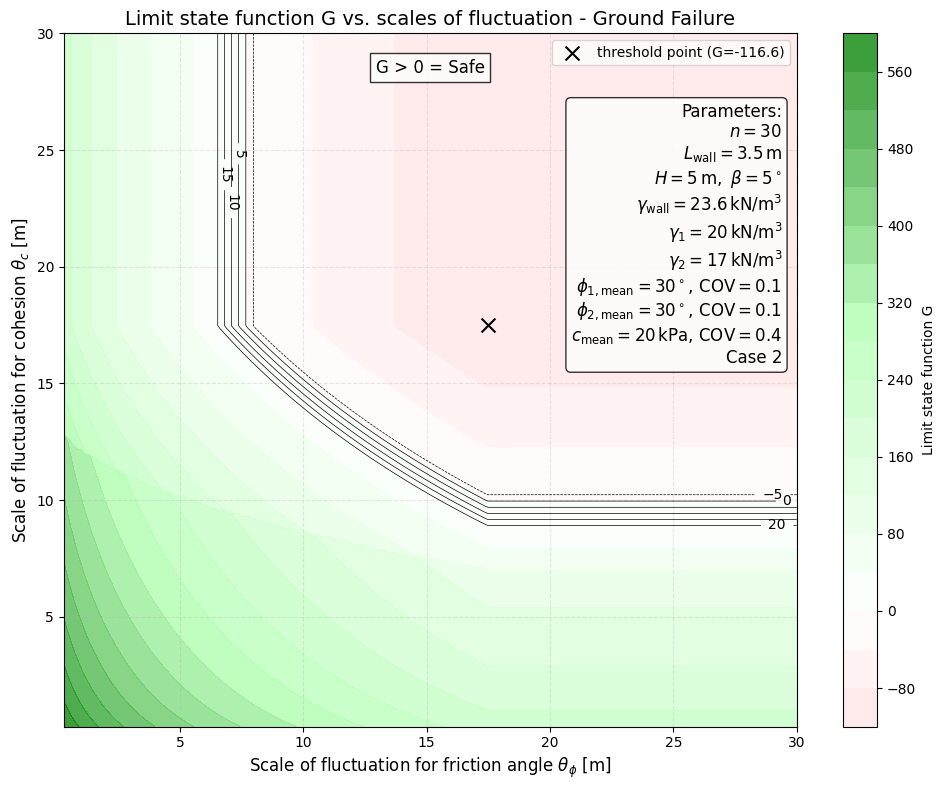

In [8]:

# Define parameter ranges
theta_phi_grid, theta_c_grid = np.meshgrid(theta_range, theta_range)

# Calculate G values for all combinations
G_values = np.zeros_like(theta_phi_grid)
for i in range(len(theta_range)):
    for j in range(len(theta_range)):
        
        theta_phi=theta_phi_grid[i,j]
        theta_c=theta_c_grid[i,j]

        phi1_k = characteristic_value (phi1_mean, phi1_cov_0, theta_phi, l_sum, Case, n_0)
        phi2_k = characteristic_value (phi2_mean, phi2_cov_0, theta_phi, l_sum, Case, n_0)
        c_k = characteristic_value (c_mean, c_cov_0, theta_c, l_sum, Case, n_0)

        G_values[i,j]  = delta_action_and_G (B_0, L_wall_0, H_0, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k) [1]

print (G_values)

# Create the plot
plt.figure(figsize=(10, 8))

# --- threshold Fix: Symmetric Normalization Around Zero ---
G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red (near zero)
    (1, 1, 1),        # Pure white at zero
    (0.7, 1.0, 0.7),  # Light green (near zero)
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=512)


# Create contour plot
contour = plt.contourf(theta_phi_grid, theta_c_grid, G_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Limit state function G')

# Add contour lines
CS = plt.contour(theta_phi_grid, theta_c_grid, G_values, 
                levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the threshold point (minimum G)
min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
plt.scatter(theta_phi_grid[min_idx], theta_c_grid[min_idx], 
           color='black', marker='x', s=100, label=f'threshold point (G={G_values[min_idx]:.1f})')

# Formatting
plt.xlabel(r'Scale of fluctuation for friction angle $\theta_\phi$ [m]', fontsize=12)
plt.ylabel(r'Scale of fluctuation for cohesion $\theta_c$ [m]', fontsize=12)
plt.title('Limit state function G vs. scales of fluctuation - Ground Failure', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

#Add parameter list as text box (upper right corner)
param_text = (
    rf"Parameters:" + "\n"
    rf"$n = {n_0}$" + "\n"
    rf"$L_{{\mathrm{{wall}}}} = {L_wall_0}\, \mathrm{{m}}$" + "\n"
    rf"$H = {H_0}\, \mathrm{{m}},\ \beta = {beta}^\circ$" + "\n"
    rf"$\gamma_{{\mathrm{{wall}}}} = {gamma_wall}\, \mathrm{{kN/m^3}}$" + "\n"
    rf"$\gamma_1 = {gamma1}\, \mathrm{{kN/m^3}}$" + "\n"
    rf"$\gamma_2 = {gamma2}\, \mathrm{{kN/m^3}}$" + "\n"
    rf"$\phi_{{1,\mathrm{{mean}}}} = {phi1_mean}^\circ$, $\mathrm{{COV}} = {phi1_cov_0}$" + "\n"
    rf"$\phi_{{2,\mathrm{{mean}}}} = {phi2_mean}^\circ$, $\mathrm{{COV}} = {phi2_cov_0}$" + "\n"
    rf"$c_{{\mathrm{{mean}}}} = {c_mean}\, \mathrm{{kPa}}$, $\mathrm{{COV}} = {c_cov_0}$" + "\n"
    rf"Case {Case}"
)

plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()

plt.show()

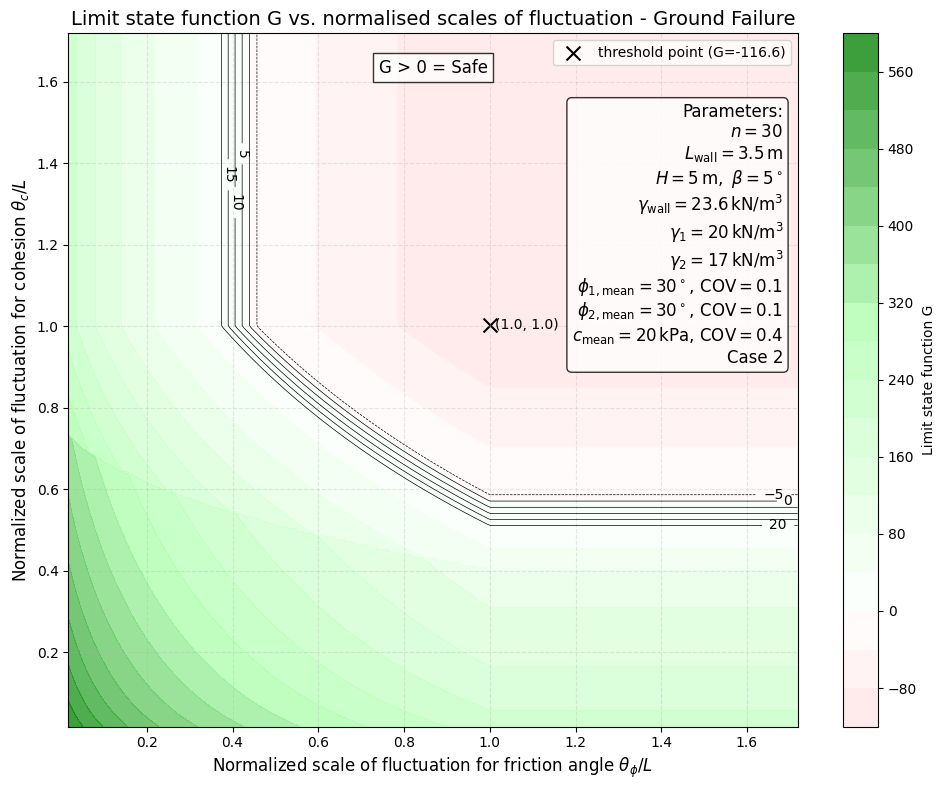

In [9]:
L_infl = l_sum  

# Create normalized grids (theta/L)
theta_phi_normalized = theta_phi_grid / L_infl
theta_c_normalized = theta_c_grid / L_infl

# Create the plot
plt.figure(figsize=(10, 8))

# --- threshold Fix: Symmetric Normalization Around Zero ---
G_max = np.max(np.abs(G_values))  # Largest magnitude (positive or negative)
vmin, vmax = -G_max, G_max  # Ensures zero is centered in the colormap

# Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red (near zero)
    (1, 1, 1),        # Pure white at zero
    (0.7, 1.0, 0.7),  # Light green (near zero)
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=512)


# Create contour plot
contour = plt.contourf(theta_phi_normalized, theta_c_normalized, G_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Limit state function G')

# Add contour lines
CS = plt.contour(theta_phi_normalized, theta_c_normalized, G_values, 
                levels=[-5, 0, 5, 10, 15, 20], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the threshold point (minimum G)
min_idx = np.unravel_index(np.argmin(G_values), G_values.shape)
x_coord = theta_phi_normalized[min_idx]
y_coord = theta_c_normalized[min_idx]

# Add text label with coordinate values near the marker
plt.text(x_coord + 0.01, y_coord, f'({x_coord:.1f}, {y_coord:.1f})', 
         color='black', fontsize=10, va='center')


plt.scatter(theta_phi_normalized[min_idx], theta_c_normalized[min_idx], 
           color='black', marker='x', s=100, label=f'threshold point (G={G_values[min_idx]:.1f})')

# Formatting
plt.xlabel(r'Normalized scale of fluctuation for friction angle $\theta_\phi/L$', fontsize=12)
plt.ylabel(r'Normalized scale of fluctuation for cohesion $\theta_c/L$', fontsize=12)
plt.title('Limit state function G vs. normalised scales of fluctuation - Ground Failure', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'G > 0 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

#Add parameter list as text box (upper right corner)
param_text = (
    rf"Parameters:" + "\n"
    rf"$n = {n_0}$" + "\n"
    rf"$L_{{\mathrm{{wall}}}} = {L_wall_0}\, \mathrm{{m}}$" + "\n"
    rf"$H = {H_0}\, \mathrm{{m}},\ \beta = {beta}^\circ$" + "\n"
    rf"$\gamma_{{\mathrm{{wall}}}} = {gamma_wall}\, \mathrm{{kN/m^3}}$" + "\n"
    rf"$\gamma_1 = {gamma1}\, \mathrm{{kN/m^3}}$" + "\n"
    rf"$\gamma_2 = {gamma2}\, \mathrm{{kN/m^3}}$" + "\n"
    rf"$\phi_{{1,\mathrm{{mean}}}} = {phi1_mean}^\circ$, $\mathrm{{COV}} = {phi1_cov_0}$" + "\n"
    rf"$\phi_{{2,\mathrm{{mean}}}} = {phi2_mean}^\circ$, $\mathrm{{COV}} = {phi2_cov_0}$" + "\n"
    rf"$c_{{\mathrm{{mean}}}} = {c_mean}\, \mathrm{{kPa}}$, $\mathrm{{COV}} = {c_cov_0}$" + "\n"
    rf"Case {Case}"
)

plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()

plt.show()

c:\Users\glori\anaconda3\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


                     ST   ST_conf
phi1_cov       0.000839  0.000277
phi2_cov       0.092162  0.014209
n              0.011131  0.002041
c_cov          0.009604  0.001773
theta_phi      0.029828  0.005327
theta_c        0.011660  0.001992
L_wall         0.747812  0.092569
H              0.084287  0.011413
beta           0.001454  0.000502
gamma_wall_SA  0.001690  0.000309
gamma1_SA      0.004838  0.001084
gamma2_SA      0.025404  0.003943
                     S1   S1_conf
phi1_cov      -0.002936  0.004048
phi2_cov       0.087024  0.032741
n              0.006432  0.014948
c_cov          0.010184  0.012762
theta_phi      0.020302  0.022447
theta_c        0.009080  0.014080
L_wall         0.735748  0.095787
H              0.075284  0.035587
beta          -0.001592  0.005672
gamma_wall_SA  0.001494  0.006225
gamma1_SA      0.000889  0.009490
gamma2_SA      0.024437  0.019114
                                  S2   S2_conf
(phi1_cov, phi2_cov)       -0.000152  0.005878
(phi1_cov, n)         

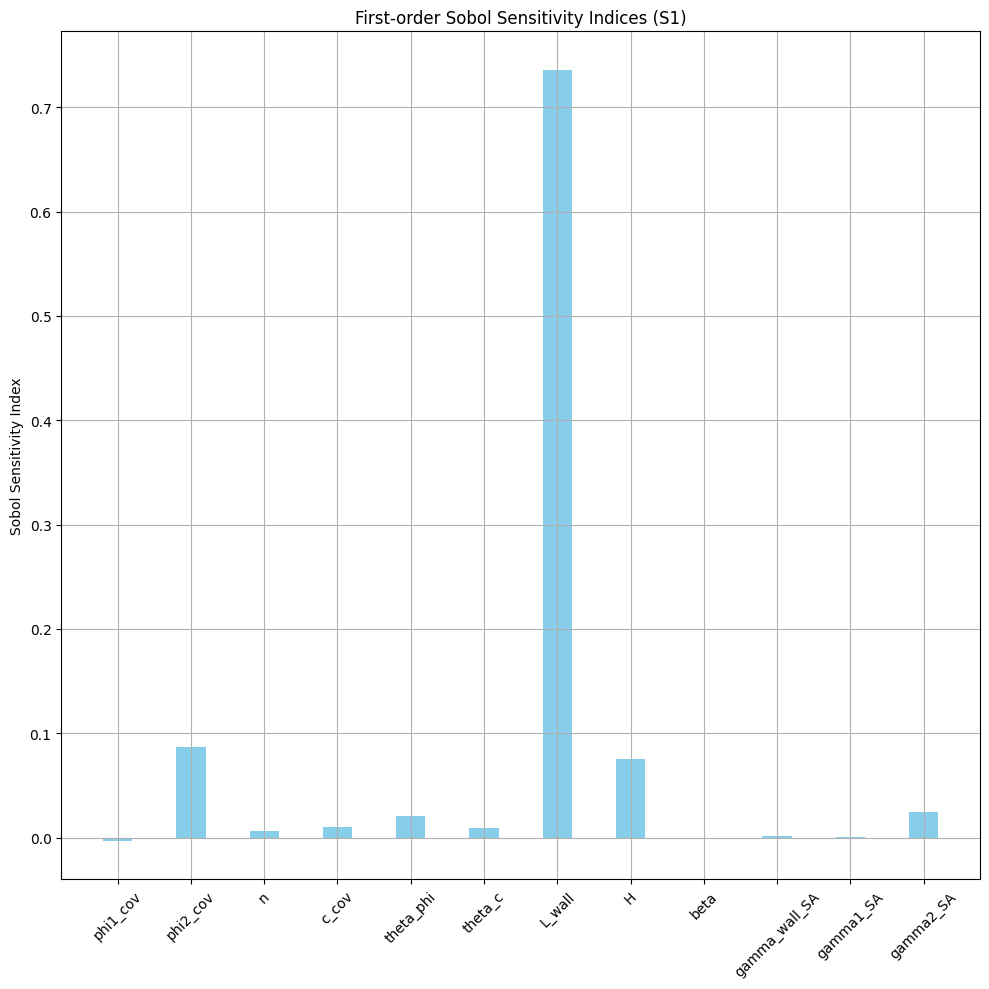

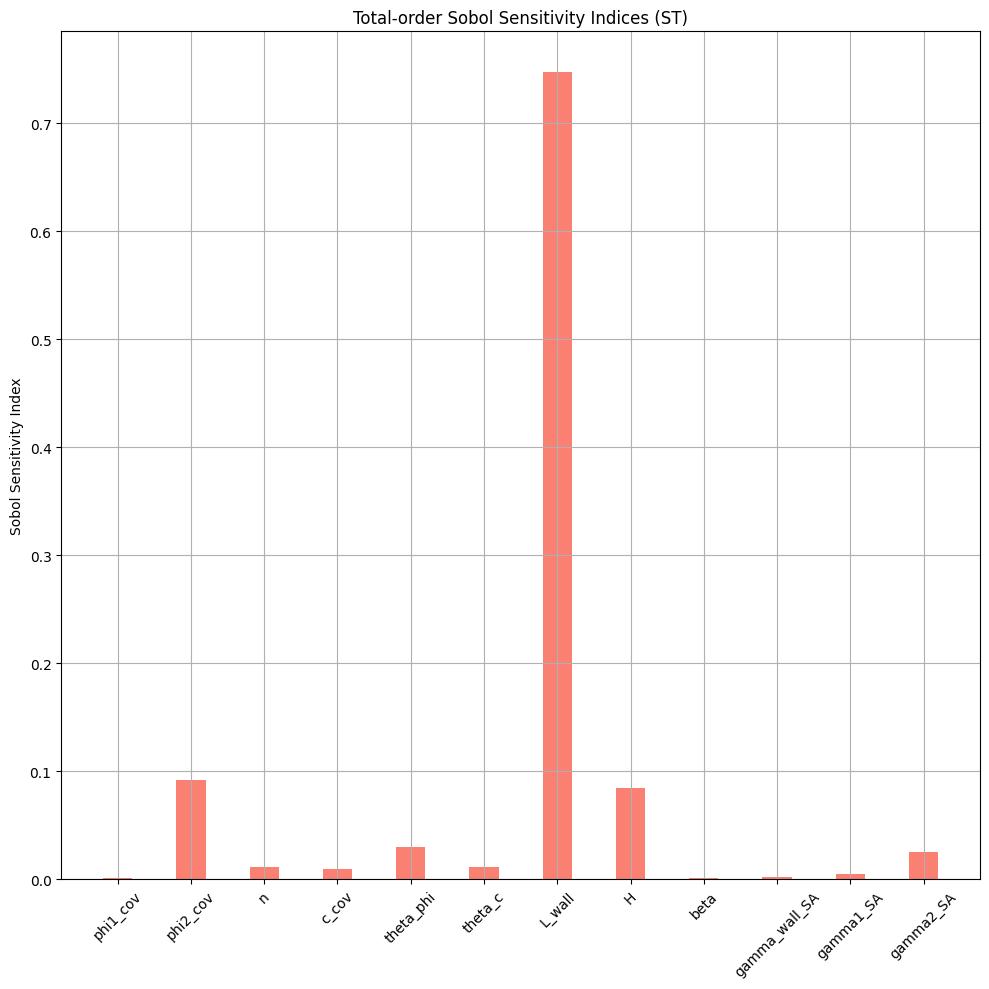

In [10]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol
import matplotlib.pyplot as plt

problem = {
    "num_vars": 12,
    "names": [
        "phi1_cov",
        "phi2_cov",
        "n",
        "c_cov",
        "theta_phi", 
        "theta_c",
        "L_wall",
        "H", 
        "beta",
        "gamma_wall_SA",
        "gamma1_SA",
        "gamma2_SA"
    ],
    "bounds": [
        [0.05, 0.15], # EC-7
        [0.05, 0.15], # EC-7
        [10, 30],
        [0.3, 0.5], # EC-7
        [1, 7],
        [1, 7], 
        [3,6],
        [4,7],
        [0,10],
        [20,25],
        [16,21],
        [16,21]
    ]
}

# --- Generate Sobol samples ---
N = 512  # base sample size
param_values = sobol_sample.sample(problem, N, calc_second_order=True)

# --- Evaluate the model for each sample ---
def evaluate_model(X):
    outputs = []
    for row in X:
        phi1_cov_SA, phi2_cov_SA, n_SA, c_cov_SA, theta_phi_SA, theta_c_SA, L_wall_SA, H_SA, beta_SA, gamma_wall_SA, gamma1_SA, gamma2_SA = row
        n_SA = int(round(n_SA))
        B_SA = L_wall_SA / 1.25

        delta_SA = delta_action_and_G (B_SA, L_wall_SA, H_SA, beta_SA, gamma_wall_SA, gamma1_SA, gamma2_SA, phi1_mean, phi2_mean, c_mean)[0] # we assume the true delta
        l_sum_SA = characteristic_length (alpha_4017, beta_4017, phi2_mean, delta_SA, L_wall_SA) # we assume the true l

        phi1_k = characteristic_value (phi1_mean, phi1_cov_SA, theta_phi_SA, l_sum_SA, Case, n_SA)
        phi2_k = characteristic_value (phi2_mean, phi2_cov_SA, theta_phi_SA, l_sum_SA, Case, n_SA)
        c_k = characteristic_value (c_mean, c_cov_SA, theta_c_SA, l_sum_SA, Case, n_SA)

        # phi1_d = degrees(atan(tan(radians(phi1_k)) / gamma_phi))
        # phi2_d = degrees(atan(tan(radians(phi2_k)) / gamma_phi))
        # c_d = c_k / gamma_c

        G = delta_action_and_G (B_SA, L_wall_SA, H_SA, beta_SA, gamma_wall_SA, gamma1_SA, gamma2_SA, phi1_k, phi2_k, c_k) [1]
        
        outputs.append(G)

    return np.array(outputs)

Y = evaluate_model(param_values)
Y = np.nan_to_num(Y, nan=np.max(Y[np.isfinite(Y)]) )  # Replace nan with large value

# --- Sobol analysis ---
Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# --- Plot S1 ---
fig1, ax1 = plt.subplots(figsize=(10, 10))
x_labels = problem["names"]
x = np.arange(len(x_labels))

ax1.bar(x, Si["S1"], width=0.4, label="First-order (S1)", color='skyblue')
ax1.set_ylabel("Sobol Sensitivity Index")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_title("First-order Sobol Sensitivity Indices (S1)")
ax1.grid(True)
plt.tight_layout()
plt.show()

# --- Plot ST ---
fig2, ax2 = plt.subplots(figsize=(10, 10))
ax2.bar(x, Si["ST"], width=0.4, label="Total-order (ST)", color='salmon')
ax2.set_ylabel("Sobol Sensitivity Index")
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=45)
ax2.set_title("Total-order Sobol Sensitivity Indices (ST)")
ax2.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# from matplotlib import cm
# import numpy as np

# # --- Plot S2 (Interaction Effects) ---
# fig3, ax3 = plt.subplots(figsize=(10, 8))

# # Get the S2 matrix
# S2_matrix = Si['S2']

# # Create a mask for the upper triangle (since the matrix is symmetric)
# mask = np.triu(np.ones_like(S2_matrix, dtype=bool))

# # Create a heatmap of the S2 values
# im = ax3.imshow(S2_matrix, cmap=cm.viridis, vmin=0, vmax =0.1 ) # vmax=np.nanmax(S2_matrix)

# # Add colorbar
# cbar = fig3.colorbar(im, ax=ax3)
# cbar.set_label('Second-order Sobol Index')

# # Set ticks and labels
# ax3.set_xticks(np.arange(len(problem['names'])))
# ax3.set_yticks(np.arange(len(problem['names'])))
# ax3.set_xticklabels(problem['names'], rotation=45)
# ax3.set_yticklabels(problem['names'])

# # Add values to each cell
# for i in range(len(problem['names'])):
#     for j in range(len(problem['names'])):
#         if not mask[i,j]:  # Only show lower triangle
#             if not np.isnan(S2_matrix[i,j]):
#                 text = ax3.text(j, i, f"{S2_matrix[i,j]:.2f}",
#                               ha="center", va="center", color="w")

# ax3.set_title("Second-order Sobol Indices (Interaction Effects)")
# plt.tight_layout()
# plt.show()

In [12]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Define parameter ranges
theta_vals = theta_range
cov_vals = np.linspace(0.05, 0.5, 20)
H_vals = np.linspace(1, 10, 19) #10
L_vals = np.linspace(2, 5.5, 14) #9
B_vals = L_vals / 1.25 # we fix the ratio for a easier setting

def plot_G(vary='phi1_theta', H=4, 
           L_wall=3.5,
           phi1_cov=0.25, phi1_theta=5,
           phi2_cov=0.25, phi2_theta=5,
           c_cov=0.25, c_theta=5):
    
    if vary == 'phi1_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{\phi_1}$ (m)'
    elif vary == 'phi2_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{\phi_2}$ (m)'
    elif vary == 'c_theta':
        x_vals = theta_vals
        x_label = r'$\theta_{c}$ (m)'
    elif vary == 'phi1_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{\phi_1}$'
    elif vary == 'phi2_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{\phi_2}$'
    elif vary == 'c_cov':
        x_vals = cov_vals
        x_label = r'CoV$_{c}$'
    elif vary == 'H':
        x_vals = H_vals
        x_label = r'$H$ (m)'
    elif vary == 'B':
        x_vals = B_vals
        x_label = r'$B$ (m)'
    elif vary == 'L_wall':
        x_vals = L_vals
        x_label = r'$L_{\text{wall}}$ (m)'
    else:
        return
    
    G_vals = []
    for x in x_vals:
        # Vary one parameter at a time
        H_x = x if vary == 'H' else H
        # B_x = x if vary == 'B' else B
        L_x = x if vary == 'L_wall' else L_wall
        phi1_cov_x = x if vary == 'phi1_cov' else phi1_cov
        phi2_cov_x = x if vary == 'phi2_cov' else phi2_cov
        c_cov_x = x if vary == 'c_cov' else c_cov
        phi1_theta_x = x if vary == 'phi1_theta' else phi1_theta
        phi2_theta_x = x if vary == 'phi2_theta' else phi2_theta
        c_theta_x = x if vary == 'c_theta' else c_theta

        try:
            # Calculate delta, characteristic length as our truth
            B_x = L_x/1.25
            delta = delta_action_and_G(B_x, L_x, H_x, beta, gamma_wall, gamma1, gamma2, phi1_mean, phi2_mean, c_mean)[0]
            l_sum = characteristic_length(alpha_4017, beta_4017, phi2_mean, delta, L_x)

            # Characteristic values
            phi1_k = characteristic_value(phi1_mean, phi1_cov_x, phi1_theta_x, l_sum, Case, n_0)
            phi2_k = characteristic_value(phi2_mean, phi2_cov_x, phi2_theta_x, l_sum, Case, n_0)
            c_k = characteristic_value(c_mean, c_cov_x, c_theta_x, l_sum, Case, n_0)

            # Design values
            # phi1_d = degrees(atan(tan(radians(phi1_k)) / gamma_phi))
            # phi2_d = degrees(atan(tan(radians(phi2_k)) / gamma_phi))
            # c_d = c_k / gamma_c

            if phi1_k < beta:
                G_vals.append(np.nan)
                continue
            else:
            # Compute G
                G = delta_action_and_G(B_x, L_x, H_x, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k)[1]
                G_vals.append(G)

        except Exception as e:
            G_vals.append(np.nan)

    # Convert to array
    G_vals = np.array(G_vals)
    min_idx = np.nanargmin(G_vals)
    x_crit = x_vals[min_idx]
    G_crit = G_vals[min_idx]

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, G_vals, marker='o', linestyle='-', color='darkgreen')
    plt.plot(x_crit, G_crit, 'ro', label=f'Min G = {G_crit:.2f}\n@ {x_label} = {x_crit:.2f}')
    plt.annotate(f'{G_crit:.2f} at {x_label} = {x_crit:.2f}',
                 xy=(x_crit, G_crit),
                 xytext=(x_crit + 0.05*(x_vals[-1]-x_vals[0]), G_crit + 0.05),
                 arrowprops=dict(facecolor='red', arrowstyle='->'),
                 fontsize=10, color='red')
    
    plt.xlabel(x_label)
    plt.ylabel(r'Limit State Function $G$')
    plt.title(f'Effect of {x_label} on $G$')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Create interactive UI
interact_ui = widgets.interactive(
    plot_G,
    vary=widgets.Dropdown(
        options=['phi1_theta', 'phi2_theta', 'c_theta', 'phi1_cov', 'phi2_cov', 'c_cov', 'H', 'L_wall'],
        value='phi1_theta',
        description='Vary:',
    ),
    H=widgets.FloatSlider(min=1, max=12, step=0.5, value=4, description='H (m)'),
    #B=widgets.FloatSlider(min=1, max=6, step=0.25, value=2.5, description='B (m)'),
    L_wall=widgets.FloatSlider(min=2, max=10, step=0.25, value=3.5, description='L_wall (m)'),
    phi1_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV φ1'),
    phi1_theta=widgets.FloatSlider(min=0.5, max=30, step=0.5, value=5, description='θ φ1'),
    phi2_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV φ2'),
    phi2_theta=widgets.FloatSlider(min=0.5, max=30, step=0.5, value=5, description='θ φ2'),
    c_cov=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV c'),
    c_theta=widgets.FloatSlider(min=0.5, max=30, step=0.5, value=5, description='θ c'),
)

display(interact_ui)


interactive(children=(Dropdown(description='Vary:', options=('phi1_theta', 'phi2_theta', 'c_theta', 'phi1_cov'…

In [ ]:
from scipy.stats import linregress


threshold_theta = []

for L_wall in L_vals:
    B = L_wall / 1.25  # for simplicity, we fixed ratio
    min_G = float('inf')
    worst_theta = None

    for theta in theta_vals:
        try:
            # Step 1: calculate delta and l_sum with means
            delta = delta_action_and_G(B, L_wall, H_0, beta, gamma_wall, gamma1, gamma2, phi1_mean, phi2_mean, c_mean)[0]
            l_sum = characteristic_length(alpha_4017, beta_4017, phi2_mean, delta, L_wall)

            # Step 2: compute characteristic values
            phi1_k = characteristic_value(phi1_mean, phi1_cov_0, theta, l_sum, Case, n_0)
            phi2_k = characteristic_value(phi2_mean, phi2_cov_0, theta, l_sum, Case, n_0)
            c_k = characteristic_value(c_mean, c_cov_0, theta, l_sum, Case, n_0)

            if phi1_k < beta:
                continue

            # Step 3: evaluate limit state function
            G = delta_action_and_G(B, L_wall, H_0, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k)[1]

            if G < min_G:
                min_G = G
                worst_theta = theta
        except:
            continue

    threshold_theta.append(worst_theta)

L_range =  np.array(L_vals)
theta_crit = np.array(threshold_theta)

#Linear regression
slope, intercept, r_value, p_value, std_err = linregress(L_range, theta_crit)

plt.figure(figsize=(8, 5))
plt.plot(L_range, theta_crit, 'o-', label='Threshold $\\theta$')
plt.plot(L_range, slope * L_range + intercept, 'r--', label='Linear Fit')

# Regression annotation
eq_text = rf"$\theta_{{\mathrm{{threshold}}}} = {slope:.2f} \cdot L_{{\mathrm{{wall}}}}  + {intercept:.2f}$"
plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

# Parameter description
param_text = (
    f"Parameters:\n"
    f"$H = {H_0}\\ \\mathrm{{m}}$\n"
    f"$\\phi_1$: mean = {phi1_mean}° , COV = {phi1_cov_0}\n"
    f"$\\phi_2$: mean = {phi2_mean}° , COV = {phi2_cov_0}\n"
    f"$c$: mean = {c_mean}kPa, COV = {c_cov_0}\n"
    f"Case {Case}, $n = {n_0}$"
)
plt.text(
    0.65, 0.5, param_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

# Labels
plt.xlabel(r'Foundation Width $L_{\mathrm{wall}}$ (m)')
plt.ylabel(r'Threshold Scale of Fluctuation $\theta$ (m)')
plt.title('Threshold Scale of Fluctuation vs Wall Width in ground failure')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



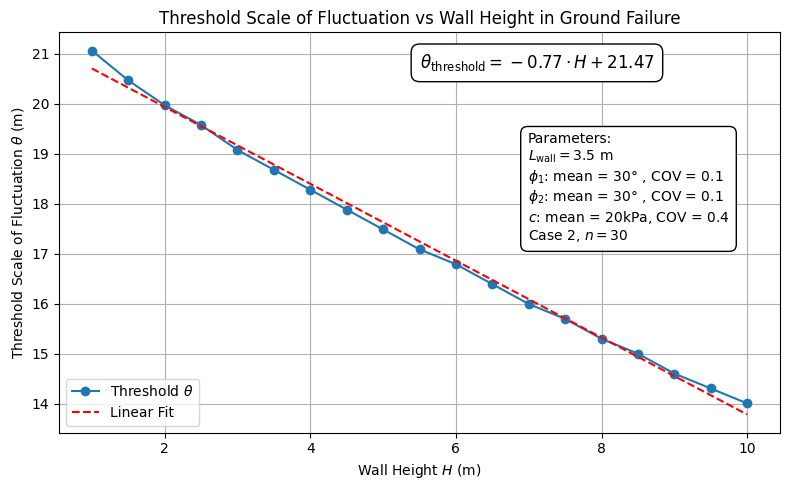

In [ ]:

threshold_theta = []

for H in H_vals:
    B = L_wall_0 / 1.25
    min_G = float('inf')
    worst_theta = None

    for theta in theta_vals:
        try:
            delta = delta_action_and_G(B, L_wall_0, H, beta, gamma_wall, gamma1, gamma2, phi1_mean, phi2_mean, c_mean)[0]
            l_sum = characteristic_length(alpha_4017, beta_4017, phi2_mean, delta, L_wall_0)

            phi1_k = characteristic_value(phi1_mean, phi1_cov_0, theta, l_sum, Case, n_0)
            phi2_k = characteristic_value(phi2_mean, phi2_cov_0, theta, l_sum, Case, n_0)
            c_k = characteristic_value(c_mean, c_cov_0, theta, l_sum, Case, n_0)

            if phi1_k < beta:
                continue

            G = delta_action_and_G(B, L_wall_0, H, beta, gamma_wall, gamma1, gamma2, phi1_k, phi2_k, c_k)[1]

            if G < min_G:
                min_G = G
                worst_theta = theta
        except:
            continue

    threshold_theta.append(worst_theta)

# Run and plot
H_range= np.array(H_vals)
theta_crit = np.array(threshold_theta)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(H_range, theta_crit)

plt.figure(figsize=(8, 5))
plt.plot(H_range, theta_crit, 'o-', label='Threshold $\\theta$')
plt.plot(H_range, slope * H_range + intercept, 'r--', label='Linear Fit')

# Regression text
eq_text = rf"$\theta_{{\mathrm{{threshold}}}} = {slope:.2f} \cdot H + {intercept:.2f}$"

plt.text(
    0.5, 0.95, eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

param_text = (
    f"Parameters:\n"
    f"$L_{{\\mathrm{{wall}}}} = {L_wall_0}\\ \\mathrm{{m}}$\n"
    f"$\\phi_1$: mean = {phi1_mean}° , COV = {phi1_cov_0}\n"
    f"$\\phi_2$: mean = {phi2_mean}° , COV = {phi2_cov_0}\n"
    f"$c$: mean = {c_mean}kPa, COV = {c_cov_0}\n"
    f"Case {Case}, $n = {n_0}$"
)

plt.text(
    0.65, 0.75, param_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

# Labels
plt.xlabel(r'Wall Height $H$ (m)')
plt.ylabel(r'Threshold Scale of Fluctuation $\theta$ (m)')
plt.title('Threshold Scale of Fluctuation vs Wall Height in Ground Failure')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
